# Fashion Intelligence System

**COSC2753 Machine Learning — Assignment 2 (2026B)**

Sections 1–3 below prepare the data that Tasks 1–4 all share. They build one table,
`model_ready`, plus the fixed label encodings and the image transform every task uses.

Each subsection follows the same three steps, so that a decision is never asserted before the
evidence for it exists:

1. **The question** — what we are checking and why it could matter.
2. **What we found** — what the code above actually returned, including the checks that came
   back clean, since those are what make the next step safe.
3. **The decision** — where we genuinely had a choice, the options we rejected and why.

Scope rules for this part of the notebook:

- Only `train/` is read. The held-out test set is not touched here.
- **No train/validation split is built here.** Splitting is a modelling decision, so each task
  section builds its own — grouped on `group_id` (see §1.6).
- **Nothing is written to disk.** Everything downstream reads the in-memory frame.

In [2]:
%matplotlib inline
from pathlib import Path
from collections import Counter
from io import BytesIO
import csv
import hashlib
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from scipy.stats import chi2_contingency
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

TARGETS = ["articleType", "season", "gender", "usage"]
REQUIRED_COLUMNS = {
    "id", "gender", "masterCategory", "subCategory", "articleType",
    "baseColour", "season", "year", "usage", "productDisplayName",
}

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8b6fc0", "#e87ba4"]
MUTED = "#6b7280"


def find_project_root(start):
    for candidate in [start, *start.parents]:
        if (candidate /"datasets" / "train" / "styles_train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate train/styles_train.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
TRAIN_DIR = PROJECT_ROOT / "datasets" / "train"
TRAIN_CSV = TRAIN_DIR / "styles_train.csv"
TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"

print("Project root:", PROJECT_ROOT)
print("Training CSV available:", TRAIN_CSV.exists())
print("Training image directory available:", TRAIN_IMAGE_DIR.exists())

from matplotlib.colors import LogNorm

RANDOM_STATE = 42  # deterministic sampling for every figure below


def show_image_grid(rows, title=None, row_labels=None, scale=1.5):
    """Render a grid of images. `rows` is a list of rows, each a list of (path, caption)."""
    ncols = max(len(row) for row in rows)
    fig, axes = plt.subplots(
        len(rows), ncols,
        figsize=(scale * ncols, scale * 1.5 * len(rows) + 0.5),
        squeeze=False,
    )
    for row_index, row in enumerate(rows):
        for column_index in range(ncols):
            ax = axes[row_index][column_index]
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column_index < len(row):
                path, caption = row[column_index]
                with Image.open(path) as image:
                    ax.imshow(ImageOps.exif_transpose(image).convert("RGB"))
                if caption:
                    ax.set_title(caption, fontsize=7)
        if row_labels:
            axes[row_index][0].set_ylabel(
                row_labels[row_index], fontsize=8, rotation=0, ha="right", va="center"
            )
    if title:
        fig.suptitle(title, y=1.0, fontsize=11)
    plt.tight_layout(); plt.show()


def sample_paths(frame, n, seed_offset=0):
    """Deterministically take up to n rows from a frame that has id/path columns."""
    if len(frame) == 0:
        return []
    picked = frame.sample(n=min(n, len(frame)), random_state=RANDOM_STATE + seed_offset)
    return list(picked.itertuples(index=False))

Project root: D:\RMIT\Machine Learning\Machine-Learning-Assignment-2
Training CSV available: True
Training image directory available: True


# 1. What data do we actually have?

## 1.1 Does the CSV parse the way we think it does?

**The question.** `pd.read_csv` will read this file without raising anything, which is exactly
why we should not trust it yet. When a row carries more fields than the header declares, pandas
invents columns to hold the surplus rather than failing. If that happened here, some rows have
silently shifted and the labels in them may no longer belong to the product they describe.

So we read the file twice: once with the raw `csv` module, purely to count how many fields each
row actually has, and once with pandas to see what it made of them.

In [3]:
with TRAIN_CSV.open("r", encoding="utf-8-sig", newline="") as stream:
    csv_rows = list(csv.reader(stream))

raw_width_counts = pd.Series(Counter(len(row) for row in csv_rows[1:]), name="rows")
raw_df = pd.read_csv(TRAIN_CSV)

schema_table = pd.DataFrame({
    "Column": raw_df.columns,
    "Data type": [str(raw_df[c].dtype) for c in raw_df.columns],
    "Non-null": [int(raw_df[c].notna().sum()) for c in raw_df.columns],
    "Missing": [int(raw_df[c].isna().sum()) for c in raw_df.columns],
    "Unique": [int(raw_df[c].nunique(dropna=True)) for c in raw_df.columns],
})

print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print("Raw CSV row widths:", raw_width_counts.to_dict())
print("Absent required columns:", sorted(REQUIRED_COLUMNS - set(raw_df.columns)))
print("Unexpected columns:", sorted(set(raw_df.columns) - REQUIRED_COLUMNS))
display(schema_table)

Raw shape: 38,617 rows x 12 columns
Raw CSV row widths: {12: 38617}
Absent required columns: []
Unexpected columns: ['Unnamed: 10', 'Unnamed: 11']


,Column,Data type,Non-null,Missing,Unique
0,id,int64,38617,0,38617
1,gender,str,38617,0,5
2,masterCategory,str,38617,0,7
3,subCategory,str,38617,0,41
4,articleType,str,38617,0,125
5,baseColour,str,38603,14,46
6,season,str,38597,20,4
7,year,int64,38617,0,12
8,usage,str,38545,72,8
9,productDisplayName,str,38610,7,27550


**What we found.** Every one of the 38,617 data rows carries **12 fields**, but the header
declares only **10 columns**. The count is perfectly consistent — no row is ragged — so this is
not random corruption; the file was written with two trailing empty header fields. Pandas
absorbed them as `Unnamed: 10` and `Unnamed: 11`.

Those two columns are empty for almost every row. **21 rows populate them**, and inspecting
those rows shows fragments of product names: the source data contains unquoted commas inside
`productDisplayName`, so on those rows the field split across column boundaries.

The important negative result is *where* the spill lands. It appears only to the right of
`productDisplayName`, which is the last real column. Every label column sits to its left and is
therefore untouched. Had the shift started earlier, `usage` values would be sitting in the
`productDisplayName` column and the dataset would be unusable without manual repair.

In [4]:
overflow_columns = [c for c in raw_df.columns if str(c).startswith("Unnamed:")]
overflow_mask = (
    raw_df[overflow_columns].notna().any(axis=1)
    if overflow_columns else pd.Series(False, index=raw_df.index)
)


def repair_product_name(row):
    parts = []
    for column in ["productDisplayName", *overflow_columns]:
        value = row.get(column)
        if pd.notna(value) and str(value).strip():
            parts.append(str(value).strip())
    return ", ".join(parts) if parts else np.nan


metadata_df = raw_df.copy()
if overflow_columns:
    metadata_df.loc[overflow_mask, "productDisplayName"] = (
        metadata_df.loc[overflow_mask].apply(repair_product_name, axis=1)
    )
    metadata_df = metadata_df.drop(columns=overflow_columns)

print(f"Rows repaired: {int(overflow_mask.sum()):,}")
print(f"Cleaned shape: {metadata_df.shape[0]:,} rows x {metadata_df.shape[1]} columns")
assert len(metadata_df) == len(raw_df)
assert not [c for c in metadata_df.columns if str(c).startswith("Unnamed:")]

Rows repaired: 21
Cleaned shape: 38,617 rows x 10 columns


**The decision.** Three options were on the table.

*Drop the 21 affected rows.* Cheapest to implement, and 21 out of 38,617 is a rounding error.
Rejected because the rows are not damaged — only reformatted — and discarding valid training
data to avoid five lines of string handling is not a defensible trade.

*Leave the columns in place.* Rejected because `productDisplayName` would stay truncated on those
rows and two junk columns would propagate into every downstream merge.

*Rejoin the fragments.* Chosen. Reassembling the comma-separated pieces restores the original
string, and afterwards the row count is unchanged and no `Unnamed:` column survives — both
asserted in the cell above. Those two assertions are what let the rest of the notebook treat the
parse as clean rather than assumed clean.

## 1.2 Is `id` safe to join on?

**The question.** Everything downstream depends on `id`: it links the CSV to the image files and
is the merge key for the audit results. A duplicate or non-numeric `id` would silently fan out
rows on merge and corrupt every count that follows. This check exists to license the merges in
§1.7, not because we expect trouble.

In [5]:
numeric_ids = pd.to_numeric(metadata_df["id"], errors="coerce")
id_audit = pd.Series({
    "rows": len(metadata_df),
    "missing ids": int(metadata_df["id"].isna().sum()),
    "non-numeric ids": int(numeric_ids.isna().sum() - metadata_df["id"].isna().sum()),
    "non-positive ids": int((numeric_ids.dropna() <= 0).sum()),
    "unique ids": int(metadata_df["id"].nunique(dropna=True)),
    "duplicate id rows": int(metadata_df["id"].duplicated(keep=False).sum()),
    "exact duplicate rows": int(metadata_df.duplicated().sum()),
    "minimum id": int(numeric_ids.min()),
    "maximum id": int(numeric_ids.max()),
}, name="value")
display(id_audit.to_frame())

assert numeric_ids.notna().all() and (numeric_ids > 0).all()
assert metadata_df["id"].is_unique
metadata_df["id"] = numeric_ids.astype(int)

,value
rows,38617
missing ids,0
non-numeric ids,0
non-positive ids,0
unique ids,38617
duplicate id rows,0
exact duplicate rows,0
minimum id,1163
maximum id,51999


**What we found.** Nothing wrong, which is the useful outcome. All 38,617 values are numeric and
positive, every one is unique, and there are no exact duplicate rows. Merging on `id` cannot
change the row count, so any change in row count later in the notebook is a real finding rather
than a merge artefact.

One incidental observation shapes a later decision: the values run from **1,163 to 51,999** —
sparse and non-contiguous. `id` is a catalogue key, not a measurement. It is used as a join key
and nothing else, and in particular it is never handed to a model as a numeric feature, where its
magnitude would be meaningless.

## 1.3 Which rows can each task actually use?

**The question.** Missing labels are usually reported as one number per column and then handled
with a single "drop incomplete rows" step. That only works if the gaps overlap. If different
columns are missing on different rows, a global filter throws away rows that were perfectly
usable for three of the four tasks. So we measure availability per task, not per column.

In [6]:
missing_table = pd.DataFrame({
    "Missing": metadata_df.isna().sum(),
    "Missing %": metadata_df.isna().mean().mul(100),
}).query("Missing > 0").sort_values("Missing", ascending=False)

availability_specs = {
    "Task 1 - articleType": ["articleType"],
    "Task 2 - season": ["season"],
    "Task 3a - gender": ["gender"],
    "Task 3b - usage": ["usage"],
    "Task 3 - both labels": ["gender", "usage"],
    "All four targets": TARGETS,
}
task_availability = pd.DataFrame(
    [
        [task, ", ".join(cols), int(metadata_df[cols].notna().all(axis=1).sum()),
         metadata_df[cols].notna().all(axis=1).mean() * 100]
        for task, cols in availability_specs.items()
    ],
    columns=["Task", "Required target(s)", "Labelled rows", "Availability %"],
)

display(missing_table.style.format({"Missing %": "{:.3f}%"}))
display(task_availability.style.format({"Availability %": "{:.3f}%"}))

,Missing,Missing %
usage,72,0.186%
season,20,0.052%
baseColour,14,0.036%
productDisplayName,7,0.018%


,Task,Required target(s),Labelled rows,Availability %
0,Task 1 - articleType,articleType,38617,100.000%
1,Task 2 - season,season,38597,99.948%
2,Task 3a - gender,gender,38617,100.000%
3,Task 3b - usage,usage,38545,99.814%
4,Task 3 - both labels,"gender, usage",38545,99.814%
5,All four targets,"articleType, season, gender, usage",38525,99.762%


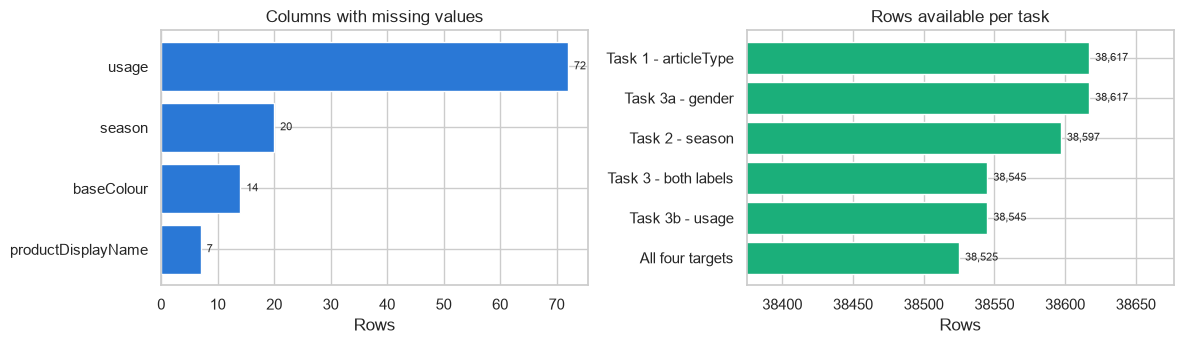

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_missing = missing_table.sort_values("Missing")
axes[0].barh(plot_missing.index, plot_missing["Missing"], color=PALETTE[0])
axes[0].set(title="Columns with missing values", xlabel="Rows")
for y, value in enumerate(plot_missing["Missing"]):
    axes[0].text(value, y, f"  {value:,}", va="center", fontsize=8)

available = task_availability.sort_values("Labelled rows")
axes[1].barh(available["Task"], available["Labelled rows"], color=PALETTE[2])
axes[1].set(title="Rows available per task", xlabel="Rows",
            xlim=(available["Labelled rows"].min() - 150, len(metadata_df) + 60))
for y, value in enumerate(available["Labelled rows"]):
    axes[1].text(value, y, f"  {value:,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**What we found.** The gaps are small but **they do not coincide**. `articleType` and `gender`
are complete across all 38,617 rows. `season` is missing on 20, `usage` on 72, `baseColour` on
14, and `productDisplayName` on 7.

Read per task instead of per column: Task 1 and Task 3a have 38,617 rows available, Task 2 has
38,597, Task 3b has 38,545, and only 38,525 rows carry all four labels at once. The right-hand
bar chart is drawn on a clipped axis deliberately — on a zero-based axis the four bars look
identical, which hides the fact that the tasks are not running on the same rows.

**The decision.** A global complete-case filter would cost 92 rows across the board. That is not
a large number, and the tempting argument is that one clean rectangular table is simpler to work
with. We rejected it anyway: those 92 rows are fully labelled for the tasks that don't need the
missing column, and dropping them means Task 1 trains on less data than exists for no reason
beyond convenience.

Instead each task gets its own boolean validity flag, built in §1.7, and filters `model_ready`
with it. The cost is that the four tasks run on slightly different row counts, which every
comparison between tasks must state.

## 1.4 Does every row have an image?

**The question.** The CSV and the image folder are separate artefacts, and nothing guarantees
they agree. We match them by filename stem and check the linkage in both directions — rows with
no file, and files with no row.

In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

manifest_rows = []
non_image_files = []
for path in sorted(TRAIN_IMAGE_DIR.iterdir(), key=lambda p: p.name.lower()):
    if not path.is_file():
        continue
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        non_image_files.append(path.name)
        continue
    try:
        image_id = int(path.stem)
    except ValueError:
        continue
    manifest_rows.append({"id": image_id, "filename": path.name, "path": str(path.resolve())})

image_manifest = pd.DataFrame(manifest_rows)
metadata_ids = set(metadata_df["id"])
image_ids = set(image_manifest["id"])

linkage_summary = pd.DataFrame([
    ["Metadata rows", len(metadata_df)],
    ["Image files found", len(image_manifest)],
    ["Metadata rows with an image", len(metadata_ids & image_ids)],
    ["Metadata rows without an image", len(metadata_ids - image_ids)],
    ["Images without metadata", len(image_ids - metadata_ids)],
    ["Duplicate image-derived ids", int(image_manifest["id"].duplicated().sum())],
    ["Non-image files ignored", len(non_image_files)],
], columns=["Linkage measure", "Count"])
display(linkage_summary)

print("Metadata ids without an image:", sorted(metadata_ids - image_ids)[:20])
assert image_manifest["id"].is_unique

,Linkage measure,Count
0,Metadata rows,38617
1,Image files found,38612
2,Metadata rows with an image,38612
3,Metadata rows without an image,5
4,Images without metadata,0
5,Duplicate image-derived ids,0
6,Non-image files ignored,1


Metadata ids without an image: [12347, 39401, 39403, 39410, 39425]


**What we found.** **38,612 of 38,617** rows have a matching image, and no image file lacks a
metadata row. Five rows have no file: `12347`, `39401`, `39403`, `39410`, `39425`.

Five rows out of 38,617 would normally not be worth a paragraph. This one is, because of *which*
row is missing. **`12347` is the only `Suits` record in the entire dataset.** Losing it means the
label space visible to an image model drops from **125 article types to 124** — a whole class
disappears, not just a handful of examples.

**The decision.** The obvious move is to drop the five rows and move on. We rejected the silent
version of that: if `Suits` vanishes without comment, any later statement about "the 124 classes
in the dataset" is quietly wrong, and a reader comparing our class count against the raw CSV will
find a discrepancy with no explanation.

So the five rows are excluded from `model_ready` (an image task cannot use a row with no image)
but the exclusion is counted and reported in §1.7, and the notebook states the class count as 124
image-observed out of 125 in metadata. The alternative — sourcing a replacement `Suits` image —
is out of scope, since the assignment restricts us to the provided data.

## 1.5 Are the image files usable, and what should we record about them?

**The question.** Two things need establishing before any modelling: that the files decode at
all, and what they look like technically, since that determines the input transform.

There is a design choice inside this loop about how much to compute. The obvious temptation is to
extract pixel statistics — brightness, saturation, edge density — while the file is open, since
the read is already paid for. We record only what a later decision depends on: readability,
dimensions, colour mode, and a SHA-256 digest. Pixel statistics were deliberately left out,
because the only statistic a model actually consumes is the normalisation constant, and that must
be fitted on training rows after a split exists — not on everything, here, where it would leak.

In [9]:
audit_rows = []
for row in image_manifest.itertuples(index=False):
    path = Path(row.path)
    record = {
        "id": int(row.id), "filename": row.filename, "path": str(path),
        "file_bytes": path.stat().st_size, "readable": False, "format": None,
        "width": np.nan, "height": np.nan, "aspect_ratio": np.nan,
        "mode": None, "is_grayscale": False, "sha256": None, "error": None,
    }
    try:
        raw_bytes = path.read_bytes()
        record["sha256"] = hashlib.sha256(raw_bytes).hexdigest()
        with Image.open(BytesIO(raw_bytes)) as image:
            image.verify()
        with Image.open(BytesIO(raw_bytes)) as image:
            detected_format = image.format
            image = ImageOps.exif_transpose(image)
            record.update({
                "readable": True, "format": detected_format,
                "width": image.width, "height": image.height,
                "aspect_ratio": image.width / image.height,
                "mode": image.mode, "is_grayscale": image.mode in {"1", "L", "I", "F"},
            })
    except Exception as error:
        record["error"] = f"{type(error).__name__}: {error}"
    audit_rows.append(record)

image_audit_df = pd.DataFrame(audit_rows)
readable_audit = image_audit_df.loc[image_audit_df["readable"]].copy()

display(pd.DataFrame([
    ["Linked image files", len(image_audit_df)],
    ["Readable", int(image_audit_df["readable"].sum())],
    ["Unreadable / corrupt", int((~image_audit_df["readable"]).sum())],
    ["Empty files", int(image_audit_df["file_bytes"].eq(0).sum())],
], columns=["Integrity measure", "Images"]))

,Integrity measure,Images
0,Linked image files,38612
1,Readable,38612
2,Unreadable / corrupt,0
3,Empty files,0


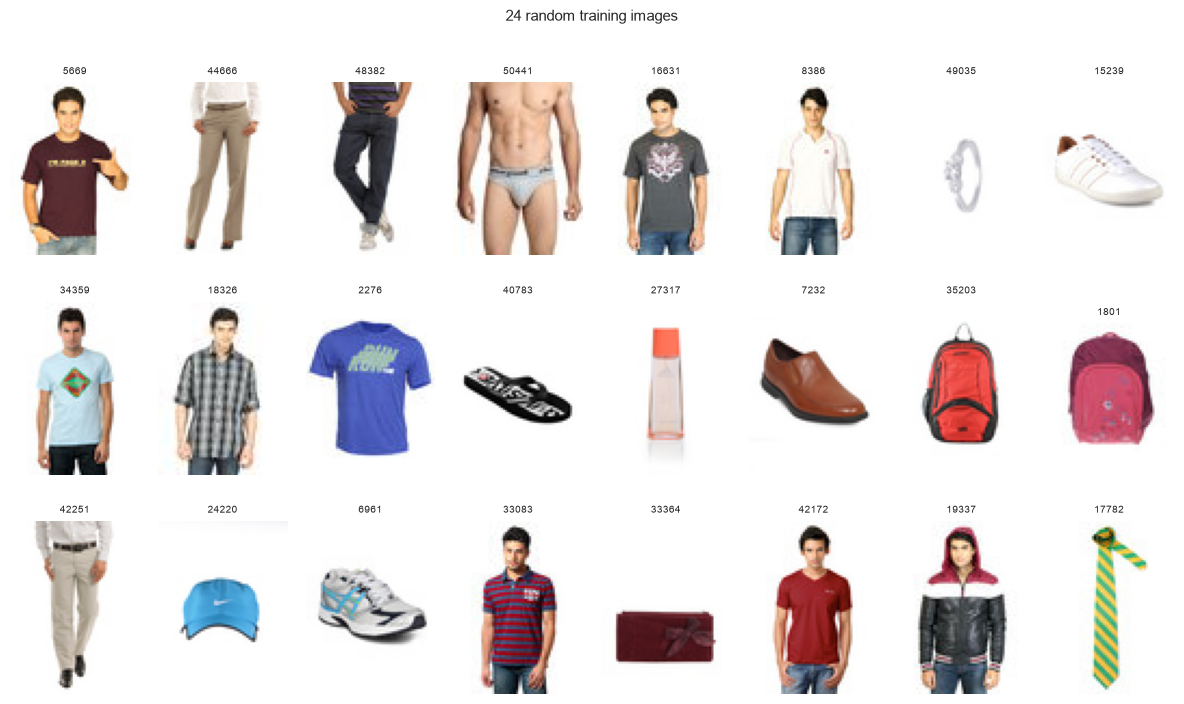

In [10]:
# What are we actually looking at? A plain sample first, before any statistics.
random_sample = sample_paths(readable_audit, 24)
show_image_grid(
    [[(r.path, str(r.id)) for r in random_sample[i:i + 8]] for i in range(0, len(random_sample), 8)],
    title="24 random training images",
)

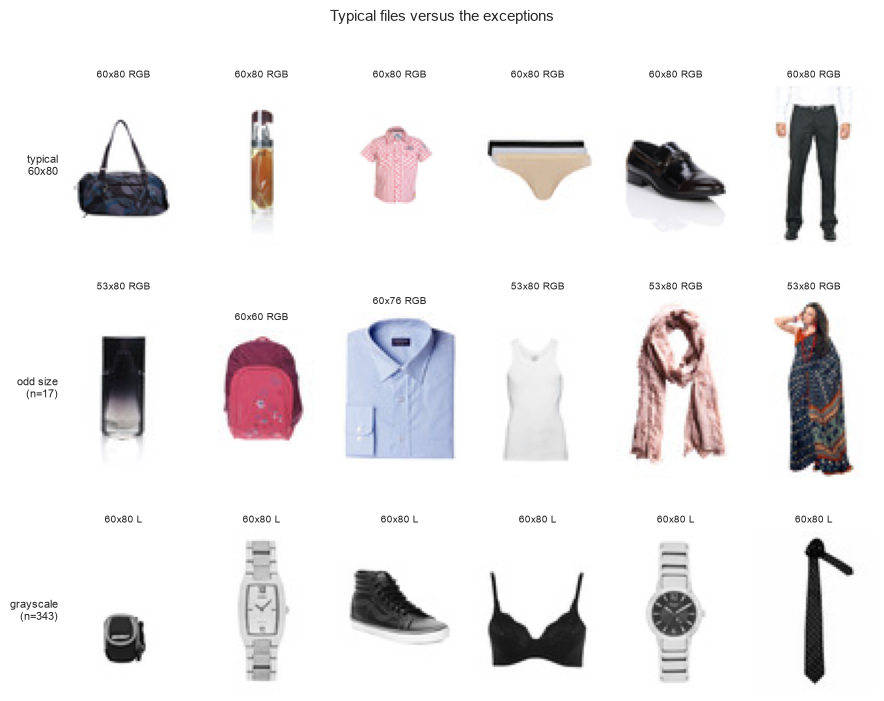

In [11]:
# Now the files that are NOT typical, since those are what the transform has to survive.
modal_dimensions = readable_audit.groupby(["width", "height"]).size().idxmax()
odd_sized = readable_audit.loc[
    (readable_audit["width"] != modal_dimensions[0]) | (readable_audit["height"] != modal_dimensions[1])
]
grayscale_files = readable_audit.loc[readable_audit["is_grayscale"]]

typical_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(
    readable_audit.loc[readable_audit["width"].eq(modal_dimensions[0])
                       & readable_audit["height"].eq(modal_dimensions[1])
                       & ~readable_audit["is_grayscale"]], 6, seed_offset=1)]
odd_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(odd_sized, 6, seed_offset=2)]
gray_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(grayscale_files, 6, seed_offset=3)]

show_image_grid(
    [row for row in [typical_row, odd_row, gray_row] if row],
    row_labels=[label for label, row in
                [(f"typical\n{modal_dimensions[0]}x{modal_dimensions[1]}", typical_row),
                 (f"odd size\n(n={len(odd_sized)})", odd_row),
                 (f"grayscale\n(n={len(grayscale_files)})", gray_row)] if row],
    title="Typical files versus the exceptions",
)

**What we found.** All **38,612** linked files decode without error. No corrupt files, no
zero-byte files, no format surprises — every one is a JPEG.

This matters more than it sounds. It means the row loss in §1.4 is the *only* row loss from
image-side problems: the set of rows with a file and the set of rows with a usable file are
identical. Every population count from here on has one explanation rather than two.

The sample sheet shows why the technical statistics come out so uniform: this is a studio
catalogue, not scraped photography — single product, centred, white background, consistent
framing. That consistency is what makes a 60x80 image enough to classify from.

The second grid is the more useful one. Placing the odd-sized and grayscale files next to typical
ones shows they are **ordinary products photographed to the same convention**, not corruption or
placeholders. That is the evidence for handling them in the transform rather than dropping them:
there is nothing wrong with these rows except their pixel geometry.

## 1.6 Are any images duplicates of each other?

**The question.** Product catalogues frequently store the same photograph under several IDs.
Exact duplicates cause two distinct problems, and it is worth separating them. The first is
**leakage**: if copies of one image land on both sides of a split, validation is scored partly on
images the model memorised. The second is **contradictory supervision**: if two copies carry
different labels, the model is being taught two answers to the identical input.

Hashing the file bytes finds exact copies. It cannot find near-duplicates — alternate views,
colourways, reshoots — which is a limitation we return to below.

In [12]:
hash_counts = readable_audit["sha256"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]
duplicate_members = readable_audit.loc[
    readable_audit["sha256"].isin(duplicate_hashes.index), ["id", "sha256"]
].merge(metadata_df[["id", *TARGETS]], on="id", how="left")

display(pd.Series({
    "readable images": len(readable_audit),
    "unique SHA-256 hashes": readable_audit["sha256"].nunique(),
    "duplicate groups": len(duplicate_hashes),
    "images in duplicate groups": int(duplicate_hashes.sum()),
    "largest duplicate group": int(duplicate_hashes.max()) if len(duplicate_hashes) else 1,
}, name="value").to_frame())

if len(duplicate_members):
    conflicts = duplicate_members.groupby("sha256")[TARGETS].nunique().gt(1).sum()
    display(conflicts.rename("groups with conflicting labels").to_frame())

,value
readable images,38612
unique SHA-256 hashes,37849
duplicate groups,636
images in duplicate groups,1399
largest duplicate group,4


,groups with conflicting labels
articleType,7
season,8
gender,7
usage,3


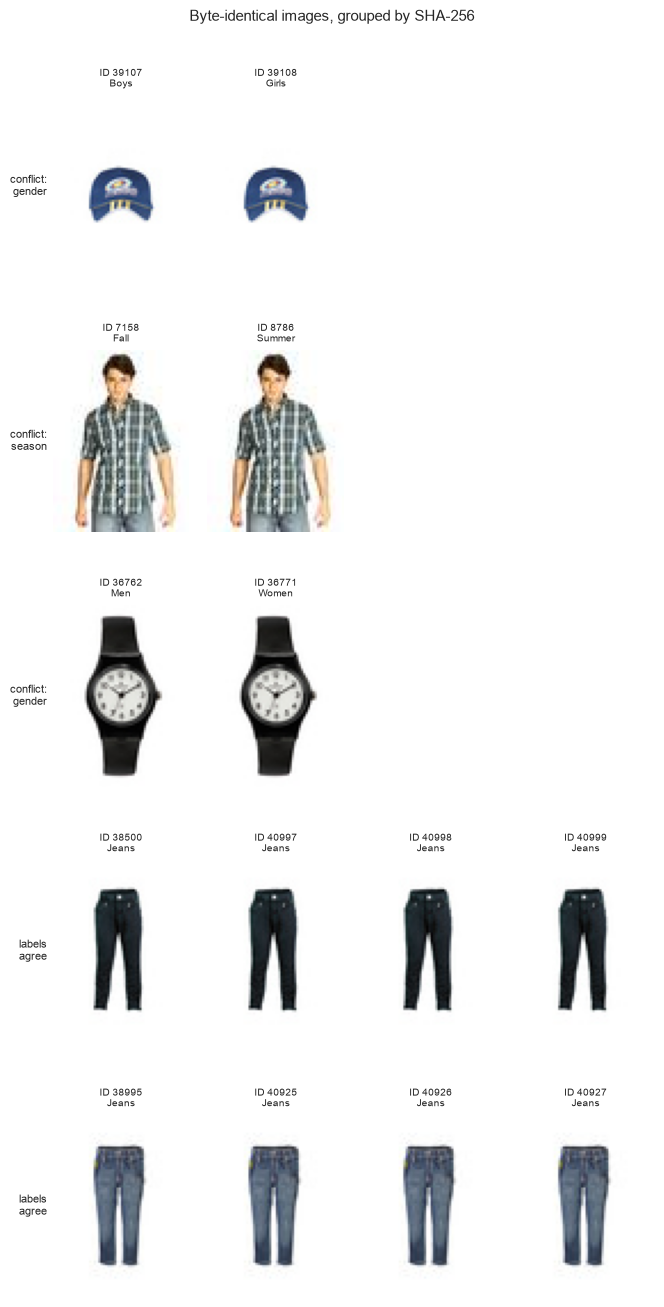

In [13]:
# Show duplicate groups as images, conflicting-label groups first - this is the label-noise evidence.
group_labels = duplicate_members.groupby("sha256")[TARGETS].nunique()
conflicting_hashes = group_labels.loc[group_labels.gt(1).any(axis=1)].index.tolist()
clean_hashes = [h for h in duplicate_hashes.index if h not in conflicting_hashes]

paths_by_id = readable_audit.set_index("id")["path"]
grid_rows, grid_labels = [], []
for digest in (conflicting_hashes[:3] + clean_hashes[:2]):
    members = duplicate_members.loc[duplicate_members["sha256"].eq(digest)]
    disagreeing = [t for t in TARGETS if members[t].nunique(dropna=True) > 1]
    row = []
    for member in members.itertuples(index=False):
        caption = f"ID {member.id}"
        for target in (disagreeing or ["articleType"]):
            caption += f"\n{getattr(member, target)}"
        row.append((paths_by_id.loc[member.id], caption))
    grid_rows.append(row)
    grid_labels.append(("conflict:\n" + ", ".join(disagreeing)) if disagreeing else "labels\nagree")

if grid_rows:
    show_image_grid(grid_rows, row_labels=grid_labels, scale=1.7,
                    title="Byte-identical images, grouped by SHA-256")

**What we found.** **636 groups covering 1,399 images**, with the largest group holding four
copies. Roughly 3.6% of the training set is duplicated content.

The label check is the more interesting result. Among those groups, **7 disagree on
`articleType`, 8 on `season`, 7 on `gender`, and 3 on `usage`**. These are byte-identical
images — the same pixels — carrying different labels. That is direct, measurable evidence of
label noise in the ground truth, and it sets a ceiling on achievable accuracy that no model
architecture can pass.

The figure makes the argument better than the table does. Each row is one hash group, so every
image in a row is *the same file*, and the captions carry the labels that disagree. A model shown
the top rows is being trained toward two different answers for one input. The bottom rows are
duplicate groups whose labels agree — harmless for supervision, but still a leakage risk if they
were split apart.

**The decision.** Deduplicating — keeping one image per hash and discarding 763 rows — is the
standard move and we rejected it. The duplicates are legitimate catalogue entries; the test set
plausibly contains the same pattern, so a model that never sees repeated products is trained on a
distribution slightly cleaner than the one it will be scored on. Deduplication also silently
picks a winner among the conflicting labels, which hides the label-noise finding rather than
documenting it.

We keep every row and carry the digest as `group_id` instead. That defuses the leakage problem
without discarding data, provided every split downstream groups on it — which is why the
divider at the end of this notebook states it as a rule rather than a suggestion.

The conflicting-label groups are left as-is. With no way to tell which label is correct, any
repair would be a guess; they stay in training as an honest sample of the noise, and Task 1
should expect a small irreducible error from them.

**Known limitation.** `group_id` catches exact copies only. Two photographs of the same shirt
from slightly different angles hash differently and can still cross a split. Perceptual hashing
would catch those; it is out of scope here, and the limitation must be stated in the report
rather than quietly ignored.

## 1.7 Assembling `model_ready`

**The question.** Everything above produced a separate frame. This step merges them into the
single table every task section starts from, and confirms the population arithmetic matches what
the preceding sections predicted.

In [14]:
manifest_link = image_manifest[["id", "filename", "path"]]
audit_flags = image_audit_df[["id", "readable", "sha256"]]

analysis_df = (
    metadata_df
    .merge(manifest_link, on="id", how="left")
    .merge(audit_flags, on="id", how="left")
)
analysis_df["image_readable"] = analysis_df["readable"].fillna(False).astype(bool)
analysis_df = analysis_df.drop(columns="readable").rename(columns={"sha256": "group_id"})

model_ready = analysis_df.loc[analysis_df["image_readable"]].copy().reset_index(drop=True)
model_ready["task1_valid"] = model_ready["articleType"].notna()
model_ready["task2_valid"] = model_ready["season"].notna()
model_ready["task3_gender_valid"] = model_ready["gender"].notna()
model_ready["task3_usage_valid"] = model_ready["usage"].notna()
model_ready["task4_valid"] = True

population_table = pd.DataFrame([
    ["Cleaned metadata rows", len(analysis_df)],
    ["Usable images (model_ready)", len(model_ready)],
    ["Task 1 - articleType", int(model_ready["task1_valid"].sum())],
    ["Task 2 - season", int(model_ready["task2_valid"].sum())],
    ["Task 3a - gender", int(model_ready["task3_gender_valid"].sum())],
    ["Task 3b - usage", int(model_ready["task3_usage_valid"].sum())],
    ["Task 4 - retrieval pool", int(model_ready["task4_valid"].sum())],
], columns=["Population", "Rows"])
display(population_table)

assert model_ready["id"].is_unique
assert model_ready["group_id"].notna().all()

,Population,Rows
0,Cleaned metadata rows,38617
1,Usable images (model_ready),38612
2,Task 1 - articleType,38612
3,Task 2 - season,38592
4,Task 3a - gender,38612
5,Task 3b - usage,38540
6,Task 4 - retrieval pool,38612


**What we found.** The table reconciles: 38,617 cleaned metadata rows in, **38,612** usable rows
out, the difference being exactly the five absent images from §1.4 and nothing else.

Per task: Task 1 and Task 3a get 38,612 rows, Task 2 gets 38,592, Task 3b gets 38,540, and Task 4
gets the full 38,612 as its retrieval pool. Note these differ slightly from the metadata-level
counts in §1.3, because each has now also lost its share of the five image-less rows.

`model_ready` carries the labels, `filename`, `group_id`, and one validity flag per task. Task
sections filter it with their own flag rather than dropping rows globally — the policy decided in
§1.3, now enforced by construction.

# 2. What is difficult about this data?

## 2.1 How are the labels distributed?

**The question.** Section 1 established which rows exist. This section asks what makes them hard
to learn from. The first thing to establish is the shape of each label space — how many classes,
and how evenly the images are spread across them.

,Target,Labelled images,Classes,Largest class,Largest support,Largest share %,Smallest support
0,articleType,38612,124,Tshirts,6780,17.6%,1
1,season,38592,4,Summer,19135,49.6%,1566
2,gender,38612,5,Men,20913,54.2%,645
3,usage,38540,8,Casual,29636,76.9%,1


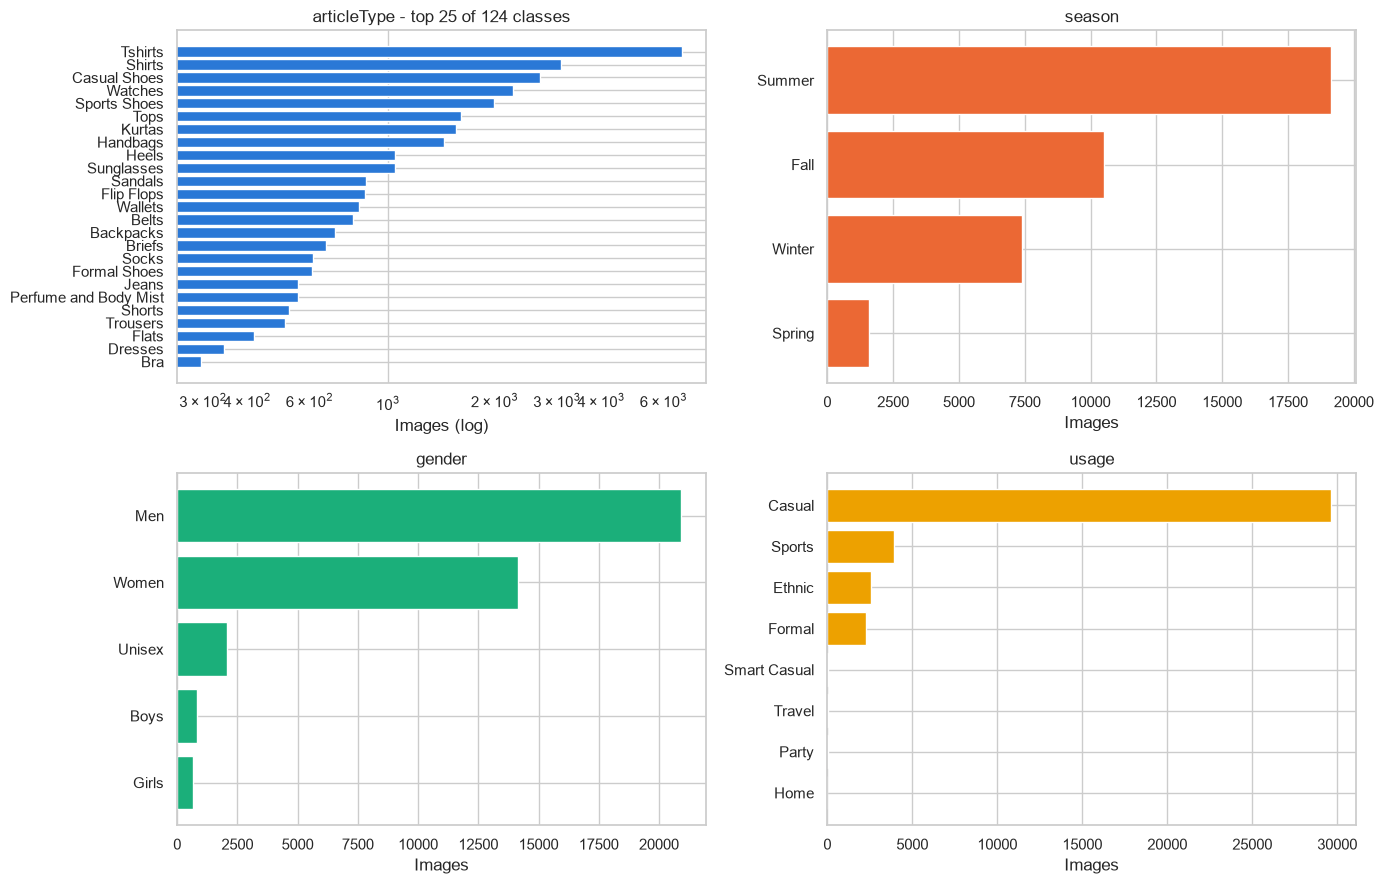

In [15]:
target_counts = {t: model_ready.loc[model_ready[t].notna(), t].value_counts() for t in TARGETS}

target_summary = pd.DataFrame([
    {
        "Target": t,
        "Labelled images": int(counts.sum()),
        "Classes": len(counts),
        "Largest class": counts.index[0],
        "Largest support": int(counts.iloc[0]),
        "Largest share %": counts.iloc[0] / counts.sum() * 100,
        "Smallest support": int(counts.iloc[-1]),
    }
    for t, counts in target_counts.items()
])
display(target_summary.style.format({"Largest share %": "{:.1f}%"}))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, target, color in zip(axes.flat, TARGETS, PALETTE[:4]):
    counts = target_counts[target]
    shown = (counts.head(25) if target == "articleType" else counts).sort_values()
    ax.barh(shown.index, shown.values, color=color)
    if target == "articleType":
        ax.set_xscale("log")
        ax.set(title=f"articleType - top 25 of {len(counts)} classes", xlabel="Images (log)")
    else:
        ax.set(title=target, xlabel="Images")
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

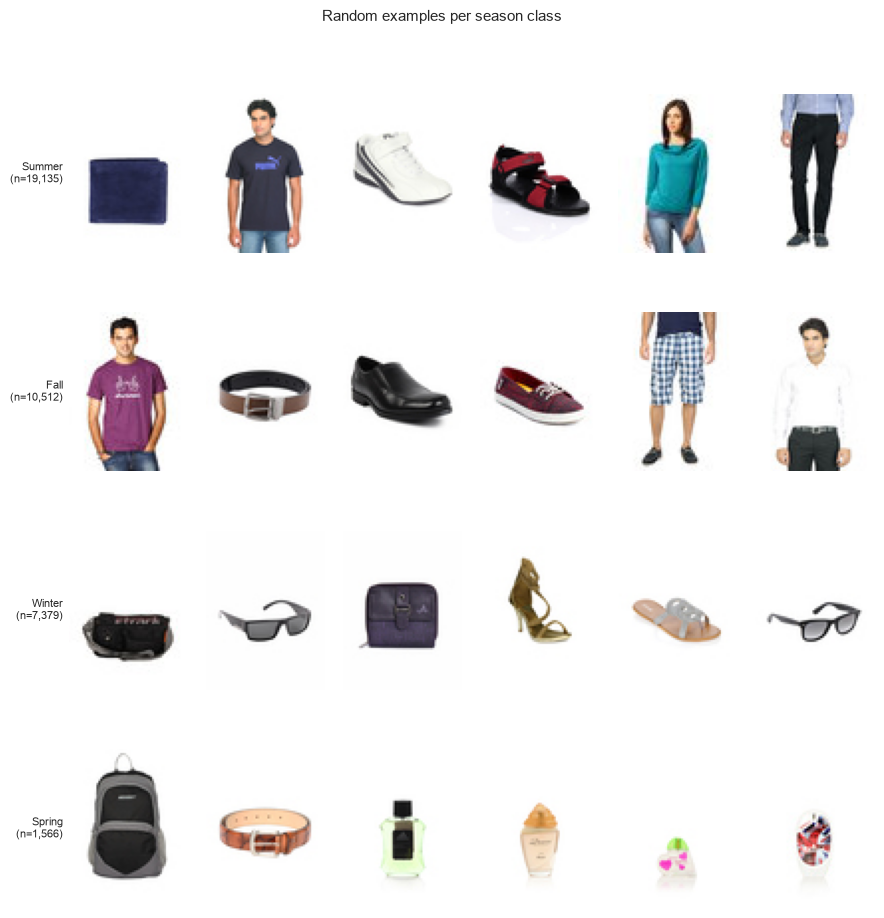

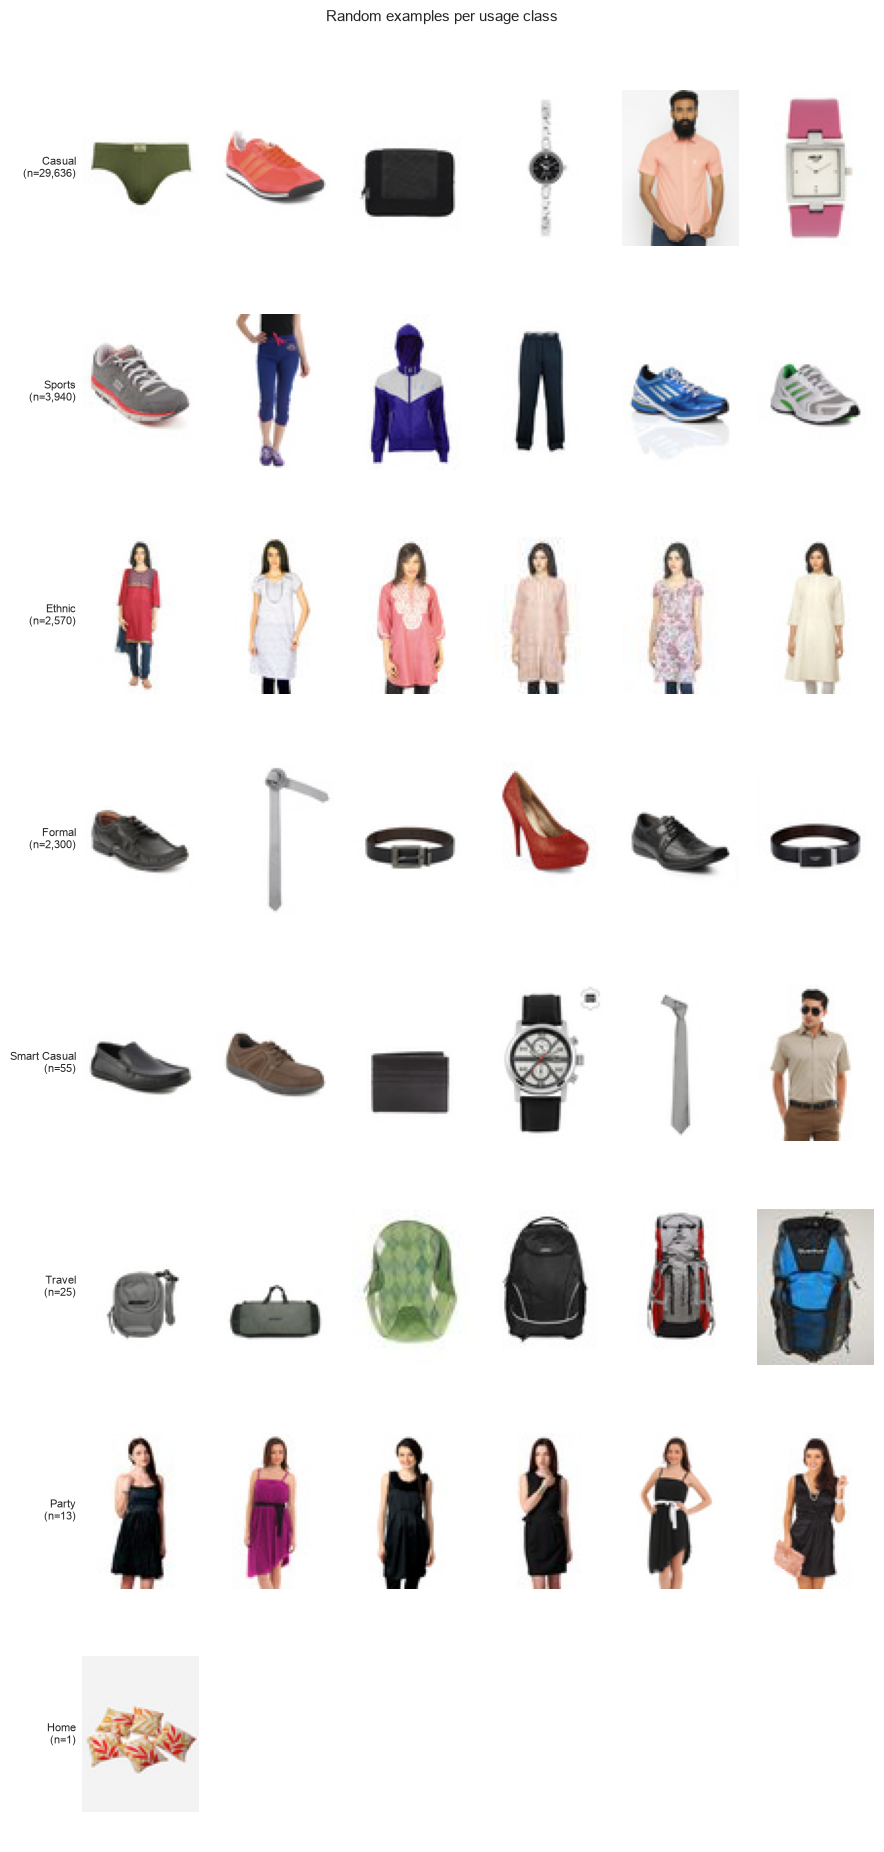

In [16]:
# Does the label look like anything? Same number of examples per class, drawn deterministically.
for target in ["season", "usage"]:
    classes = target_counts[target].index.tolist()
    rows, labels = [], []
    for label in classes:
        members = model_ready.loc[model_ready[target].eq(label), ["id", "path"]]
        picked = sample_paths(members, 6, seed_offset=hash(label) % 100)
        if picked:
            rows.append([(r.path, "") for r in picked])
            labels.append(f"{label}\n(n={target_counts[target][label]:,})")
    show_image_grid(rows, row_labels=labels, title=f"Random examples per {target} class")

**What we found.** The four targets are structurally very different problems wearing the same
interface.

`articleType` has **124 classes**, led by Tshirts at **6,780 images (17.6%)**, with the smallest
class holding a single image. `season` has **4** classes, led by Summer at **19,135 (49.6%)**.
`gender` has **5**, led by Men at **20,913 (54.2%)**. `usage` has **8**, led by Casual at
**29,636 of 38,540 — 76.9%**.

The immediate consequence is that accuracy is a broken metric here before we train anything. A
model that predicts "Casual" unconditionally scores 76.9% on Task 3b while learning nothing at
all. Any headline number in the report has to be macro-averaged, or it is measuring the class
prior rather than the model.

The example grids add something the counts cannot. Scan the `season` rows and try to name the
season from the product alone — the rows are largely interchangeable, because a plain shirt is
photographed identically whether the catalogue files it under Summer or Fall. Season is a
**merchandising attribute, not a visual one**, and any model has to infer it from weak proxies
like sleeve length or fabric weight. That is a prediction Task 2 should test: expect it to be the
hardest of the three classification tasks despite having only four classes.

The `usage` rows show the imbalance from the other side — Casual spans nearly the whole product
range, while the small classes are narrow and specific.

## 2.2 How bad is the long tail?

**The question.** A top-class share tells us the majority side. This section looks at the
minority side, because that is what decides whether rare classes are learnable at all and whether
they can even be evaluated.

,Target,Classes,Max/min ratio,Median support,Singleton classes,Classes < 5,Classes < 10,Top-class share %
0,articleType,124,"6,780.0",43.5,6,21,32,17.6%
1,season,4,12.2,"8,945.5",0,0,0,49.6%
2,gender,5,32.4,"2,080.0",0,0,0,54.2%
3,usage,8,"29,636.0","1,177.5",1,1,1,76.9%


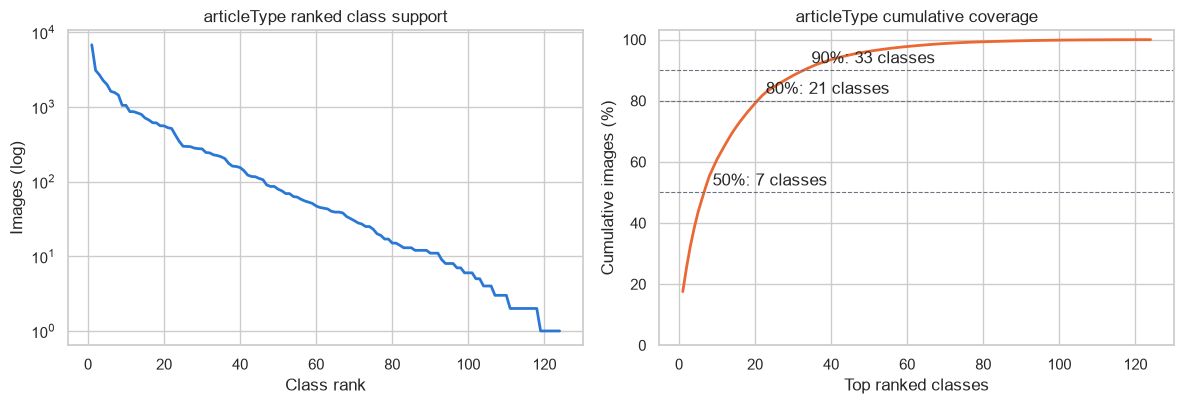

Classes needed for 50/80/90% of images: {50: 7, 80: 21, 90: 33}

Rare articleType classes (< 5 images):
{'Compact': 4, 'Lip Plumper': 4, 'Highlighter and Blush': 4, 'Hat': 3, 'Shrug': 3, 'Tablet Sleeve': 3, 'Trolley Bag': 3, 'Lehenga Choli': 2, 'Key chain': 2, 'Robe': 2, 'Shapewear': 2, 'Concealer': 2, 'Baby Dolls': 2, 'Rain Jacket': 2, 'Rain Trousers': 2, 'Shoe Laces': 1, 'Ties and Cufflinks': 1, 'Cushion Covers': 1, 'Body Wash and Scrub': 1, 'Ipad': 1, 'Lounge Tshirts': 1}


In [17]:
imbalance_table = pd.DataFrame([
    {
        "Target": t,
        "Classes": len(counts),
        "Max/min ratio": counts.max() / counts.min(),
        "Median support": counts.median(),
        "Singleton classes": int((counts == 1).sum()),
        "Classes < 5": int((counts < 5).sum()),
        "Classes < 10": int((counts < 10).sum()),
        "Top-class share %": counts.max() / counts.sum() * 100,
    }
    for t, counts in target_counts.items()
])
display(imbalance_table.style.format({
    "Max/min ratio": "{:,.1f}", "Median support": "{:,.1f}", "Top-class share %": "{:.1f}%",
}))

article_counts = target_counts["articleType"].sort_values(ascending=False)
cumulative = article_counts.cumsum() / article_counts.sum() * 100
coverage = {t: int(np.searchsorted(cumulative.values, t) + 1) for t in [50, 80, 90]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(np.arange(1, len(article_counts) + 1), article_counts.values, color=PALETTE[0], lw=2)
axes[0].set_yscale("log")
axes[0].set(title="articleType ranked class support", xlabel="Class rank", ylabel="Images (log)")
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative.values, color=PALETTE[1], lw=2)
for threshold, n_classes in coverage.items():
    axes[1].axhline(threshold, color=MUTED, ls="--", lw=0.8)
    axes[1].annotate(f"{threshold}%: {n_classes} classes", (n_classes, threshold),
                     xytext=(5, 5), textcoords="offset points")
axes[1].set(title="articleType cumulative coverage", xlabel="Top ranked classes",
            ylabel="Cumulative images (%)", ylim=(0, 103))
plt.tight_layout(); plt.show()
print("Classes needed for 50/80/90% of images:", coverage)

print("\nRare articleType classes (< 5 images):")
print(article_counts[article_counts < 5].to_dict())

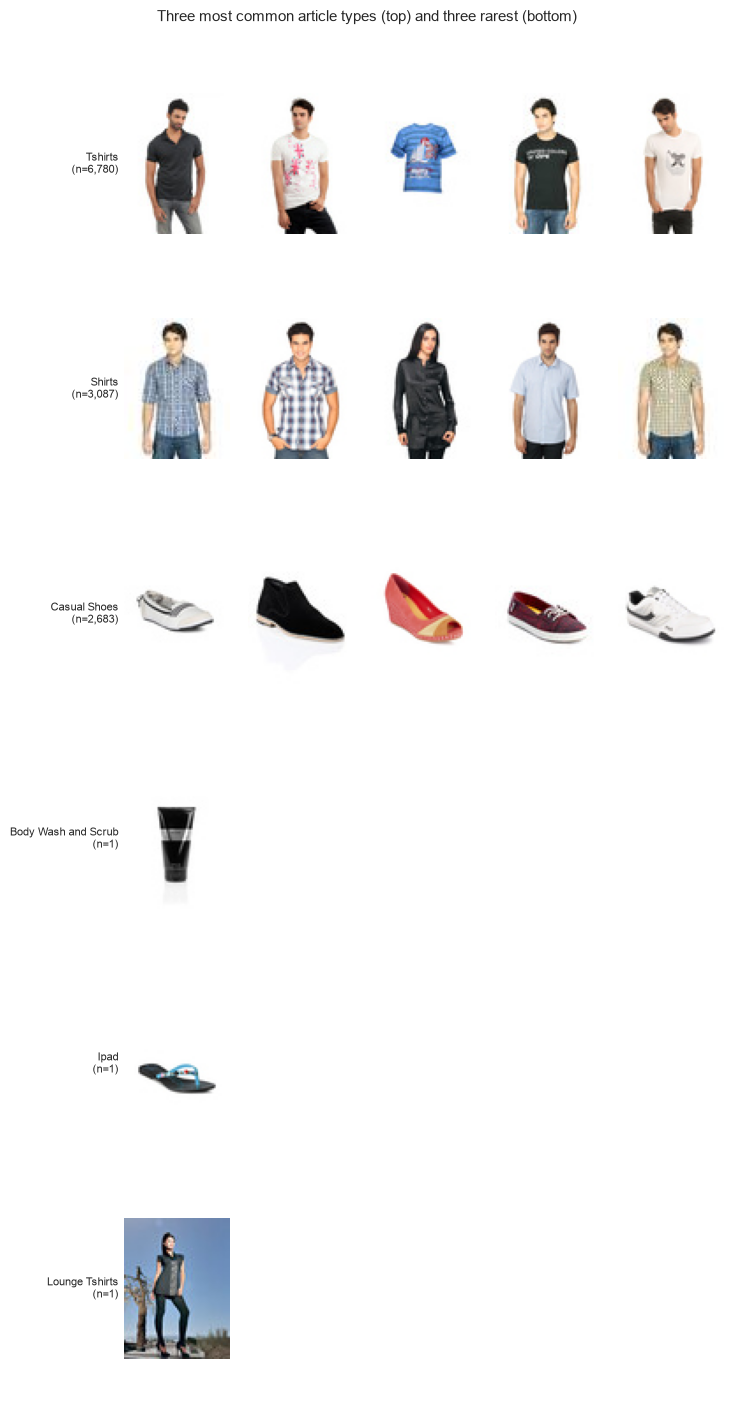

In [18]:
# The head and the tail of the articleType distribution, side by side.
head_classes = article_counts.head(3).index.tolist()
tail_classes = article_counts.tail(3).index.tolist()
rows, labels = [], []
for label in head_classes + tail_classes:
    members = model_ready.loc[model_ready["articleType"].eq(label), ["id", "path"]]
    picked = sample_paths(members, 5, seed_offset=hash(label) % 100)
    rows.append([(r.path, "") for r in picked])
    labels.append(f"{label}\n(n={article_counts[label]:,})")
show_image_grid(rows, row_labels=labels,
                title="Three most common article types (top) and three rarest (bottom)")

**What we found.** `articleType` is severely long-tailed. Support ranges from 6,780 down to 1 — a
ratio of **6,780:1**. **32 classes hold fewer than 10 images**, 21 hold fewer than 5, and 6 are
singletons. The cumulative curve is blunt about it: **7 classes cover 50% of the images, 21 cover
80%, and 33 cover 90%** — so 91 of the 124 classes share the last tenth of the data.

`usage` has a different pathology: only 8 classes, but a 29,636:1 ratio driven by one class with a
single image.

The head-versus-tail figure shows what the ratio means in practice: the common classes have
enough examples to cover pose, colour and styling variation, while the rare classes are a handful
of images that the model must generalise from — and in some rows, literally one.

The singletons have a consequence that outlives this notebook. A class with one image cannot
appear in both training and validation. Whichever side it lands on, it is either untrainable or
unevaluable — so no split can possibly cover all 124 classes in validation, and the report's
metric definition has to say which classes it scores.

**The decision.** Three standard remedies, two rejected.

*Merge rare classes into an "Other" bucket.* Rejected: it changes the problem the assignment set.
"What type of fashion item is this?" answered with "Other" is not a useful answer for a product
catalogue, and it would inflate our headline score by deleting the hard cases.

*Oversample rare classes at the dataset level.* Rejected here, but only as a *dataset-level*
policy. Duplicating a singleton 100 times before splitting guarantees the same image appears in
training and validation. Class weighting inside the loss, or sampling applied after a split, is a
legitimate experiment for the task sections — that is a model decision, not a data decision.

*Keep every class and every row.* Chosen. The label space stays at 124 with original names, and
the imbalance is handled at evaluation time by macro-averaging rather than at data-preparation
time by editing the data.

## 2.3 Which classes look alike to a model?

**The question.** Imbalance tells us which classes are *rare*. It says nothing about which are
*hard*. Two classes can each hold thousands of images and still be near-inseparable if the
catalogue photographs them the same way — and unlike rarity, no amount of class weighting fixes
that.

We probe this with class mean images: average every image of a class into one picture, which
summarises the shape, framing and colour the catalogue repeatedly presents for that label, then
rank class pairs by cosine similarity between those means. Classes below
`CONFUSABILITY_MIN_SUPPORT` are excluded, since a mean over three images is just those three
images.

The column to read is `different_product_family`. *Sandals* scoring highly against *Flip Flops*
is unremarkable — both are open footwear. Two classes from **different `subCategory` branches**
scoring highly means the catalogue makes genuinely unrelated objects look alike, and those are
the errors that will be hardest to argue away.

In [19]:
CONFUSABILITY_MIN_SUPPORT = 30
MEAN_IMAGE_SIZE = (60, 80)  # width, height

article_support = target_counts["articleType"]
confusable_classes = sorted(article_support[article_support >= CONFUSABILITY_MIN_SUPPORT].index)
print(f"{len(confusable_classes)} of {len(article_support)} article types have "
      f">= {CONFUSABILITY_MIN_SUPPORT} images and get a mean image.")

mean_sums = {label: np.zeros((MEAN_IMAGE_SIZE[1], MEAN_IMAGE_SIZE[0], 3), dtype=np.float64)
             for label in confusable_classes}
mean_counts = Counter()
for row in model_ready.loc[model_ready["articleType"].isin(confusable_classes),
                           ["path", "articleType"]].itertuples(index=False):
    with Image.open(row.path) as image:
        pixels = np.asarray(
            ImageOps.fit(ImageOps.exif_transpose(image).convert("RGB"), MEAN_IMAGE_SIZE),
            dtype=np.float32,
        )
    mean_sums[row.articleType] += pixels
    mean_counts[row.articleType] += 1

class_mean_images = {label: mean_sums[label] / mean_counts[label] for label in confusable_classes}

70 of 124 article types have >= 30 images and get a mean image.


In [20]:
# Centre each mean image before normalising so overall brightness does not dominate similarity.
mean_matrix = np.stack([class_mean_images[label].reshape(-1) for label in confusable_classes])
mean_matrix = mean_matrix - mean_matrix.mean(axis=1, keepdims=True)
mean_matrix /= np.linalg.norm(mean_matrix, axis=1, keepdims=True)
mean_similarity = mean_matrix @ mean_matrix.T

# The product family each article type belongs to, used to flag cross-family confusion.
family_of = (
    model_ready.dropna(subset=["articleType", "subCategory"])
    .groupby("articleType")["subCategory"]
    .agg(lambda s: s.value_counts().index[0])
)

pairs = []
for a in range(len(confusable_classes)):
    for b in range(a + 1, len(confusable_classes)):
        left, right = confusable_classes[a], confusable_classes[b]
        pairs.append({
            "articleType A": left,
            "articleType B": right,
            "similarity": mean_similarity[a, b],
            "family A": family_of.get(left, "unknown"),
            "family B": family_of.get(right, "unknown"),
            "different_product_family": family_of.get(left) != family_of.get(right),
            "support A": int(mean_counts[left]),
            "support B": int(mean_counts[right]),
        })
confusable_pairs = pd.DataFrame(pairs).sort_values("similarity", ascending=False).reset_index(drop=True)

print("Most similar pairs overall:")
display(confusable_pairs.head(10).style.format({"similarity": "{:.3f}"}))

cross_family = confusable_pairs.loc[confusable_pairs["different_product_family"]]
print("Most similar pairs from DIFFERENT product families - genuinely different objects "
      "that the catalogue photographs alike:")
display(cross_family.head(10).style.format({"similarity": "{:.3f}"}))

Most similar pairs overall:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
0,Kurtis,Tunics,0.992,Topwear,Topwear,False,203,175
1,Tops,Tunics,0.989,Topwear,Topwear,False,1614,175
2,Jackets,Sweatshirts,0.989,Topwear,Topwear,False,228,280
3,Kurtas,Tunics,0.986,Topwear,Topwear,False,1556,175
4,Flats,Heels,0.985,Shoes,Shoes,False,418,1048
5,Kurtis,Tops,0.984,Topwear,Topwear,False,203,1614
6,Laptop Bag,Messenger Bag,0.983,Bags,Bags,False,79,43
7,Sweaters,Sweatshirts,0.983,Topwear,Topwear,False,276,280
8,Sandals,Sports Sandals,0.982,Sandal,Sandal,False,865,63
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90


Most similar pairs from DIFFERENT product families - genuinely different objects that the catalogue photographs alike:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90
11,Stoles,Tops,0.979,Stoles,Topwear,True,90,1614
12,Stoles,Tunics,0.978,Stoles,Topwear,True,90,175
15,Innerwear Vests,Tshirts,0.974,Innerwear,Topwear,True,242,6780
17,Kurtis,Stoles,0.972,Topwear,Stoles,True,203,90
19,Casual Shoes,Sports Sandals,0.971,Shoes,Sandal,True,2683,63
21,Casual Shoes,Sandals,0.970,Shoes,Sandal,True,2683,865
22,Leggings,Lounge Pants,0.969,Bottomwear,Loungewear and Nightwear,True,159,53
25,Messenger Bag,Wallets,0.963,Bags,Wallets,True,43,829
29,Dresses,Stoles,0.959,Dress,Stoles,True,345,90


**What we found.** *(Fill the specific pairs in from your run — these depend on the images and
cannot be stated before the cells above execute.)*

Read the two tables together. The first ranking is dominated by pairs that are genuinely similar
products, and those are unsurprising. The second ranking — cross-family pairs — is the one worth
quoting in the report, because a high score there means two objects a shopper would never confuse
are nonetheless near-identical at the resolution the model sees.

The visual check below matters as a control. A high cosine similarity between two mean images can
be an artefact of averaging: if both classes are photographed centred on white with similar
overall mass, their means converge even when individual images are easy to tell apart. Comparing
the class means against real examples of each class shows which explanation applies.

Kurtas (Topwear) vs Stoles (Stoles) - cosine similarity 0.982


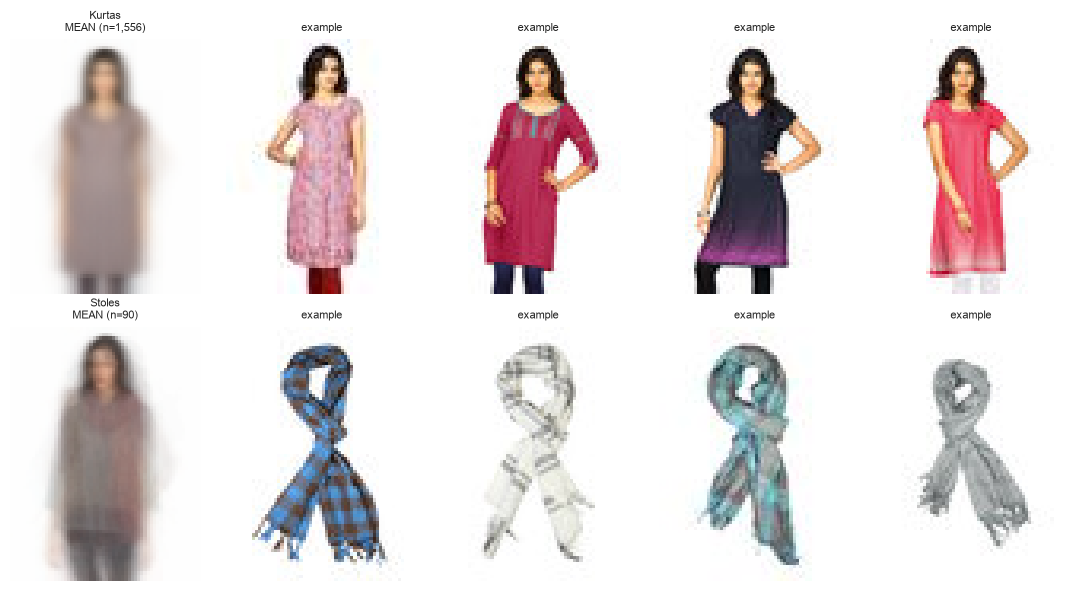

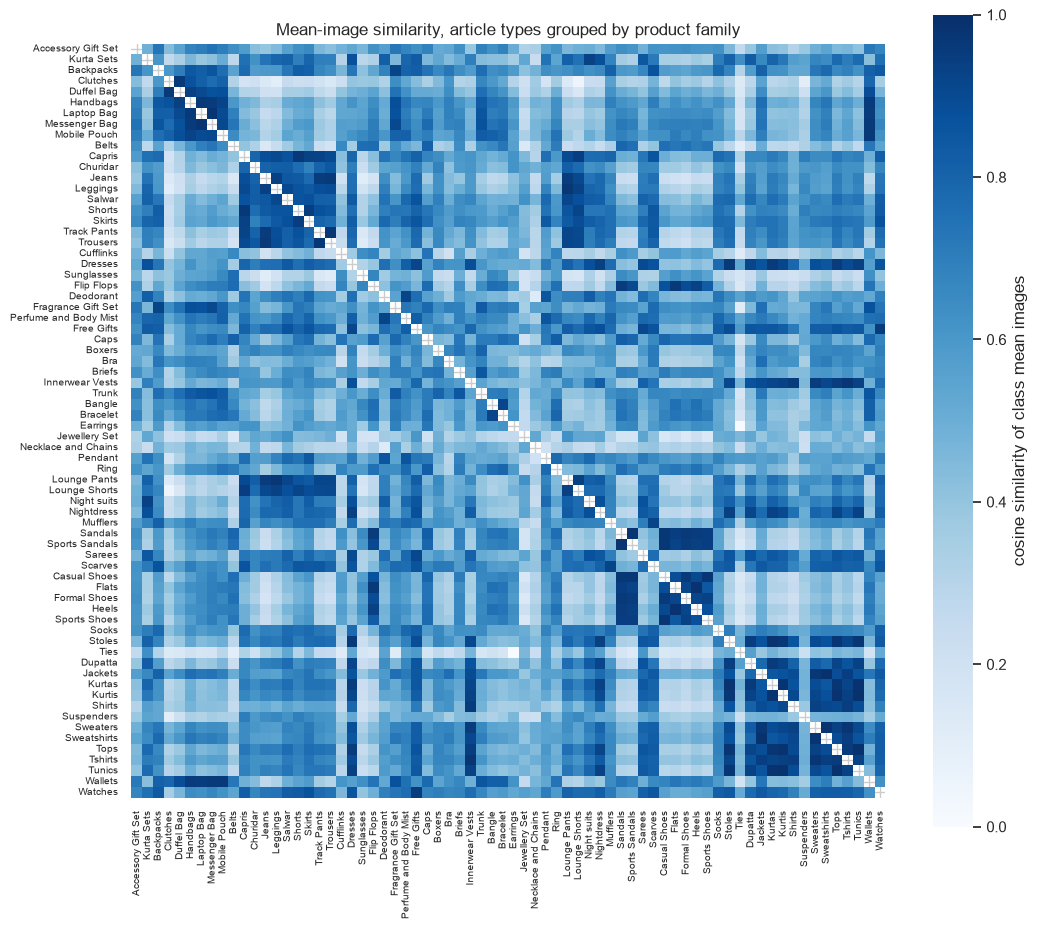

In [21]:
# Show the worst cross-family pair concretely: class means, then real examples of each.
assert len(cross_family), "No cross-family pairs; lower CONFUSABILITY_MIN_SUPPORT."
worst = cross_family.iloc[0]
pair_labels = [worst["articleType A"], worst["articleType B"]]
print(f"{pair_labels[0]} ({worst['family A']}) vs {pair_labels[1]} ({worst['family B']}) "
      f"- cosine similarity {worst['similarity']:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(11, 6))
for row_index, label in enumerate(pair_labels):
    axes[row_index, 0].imshow(class_mean_images[label].astype(np.uint8))
    axes[row_index, 0].set_title(f"{label}\nMEAN (n={mean_counts[label]:,})", fontsize=8)
    examples = model_ready.loc[model_ready["articleType"].eq(label), "path"].head(4)
    for column, example_path in enumerate(examples, start=1):
        with Image.open(example_path) as image:
            axes[row_index, column].imshow(ImageOps.exif_transpose(image).convert("RGB"))
        axes[row_index, column].set_title("example", fontsize=8)
    for ax in axes[row_index]:
        ax.axis("off")
plt.tight_layout(); plt.show()

# Similarity structure across the whole label space, grouped so families form visible blocks.
heatmap_order = sorted(confusable_classes, key=lambda label: (family_of.get(label, "unknown"), label))
position = {label: index for index, label in enumerate(confusable_classes)}
ordered = mean_similarity[np.ix_([position[l] for l in heatmap_order],
                                 [position[l] for l in heatmap_order])].copy()
np.fill_diagonal(ordered, np.nan)

fig, ax = plt.subplots(figsize=(11, 9.5))
sns.heatmap(ordered, xticklabels=heatmap_order, yticklabels=heatmap_order,
            cmap="Blues", vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "cosine similarity of class mean images"})
ax.set_title("Mean-image similarity, article types grouped by product family")
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

**What this is and is not.** These are **predictions, not results**. Nothing here has been
trained. The value is that they are falsifiable: Task 1 below should compare this ranked list
against its confusion matrix. If the pairs match, the errors have a visual explanation and the
fix is resolution or architecture. If they don't, the errors come from somewhere else — label
noise, imbalance, or optimisation — and this hypothesis is dead. Either outcome is worth
reporting; a confusion matrix with no prior prediction to test against is just a picture.

## 2.4 Is Task 3 one label or two?

**The question.** The assignment leaves this open: predict gender and usage as two targets, or
combine them into a single joint class. It is a real fork, so it needs evidence rather than
preference.

Two things decide it. How much the targets overlap — measured with bias-corrected Cramér's V,
which is appropriate here because both are unordered categorical variables with different
cardinalities. And how sparse a joint label would actually be.

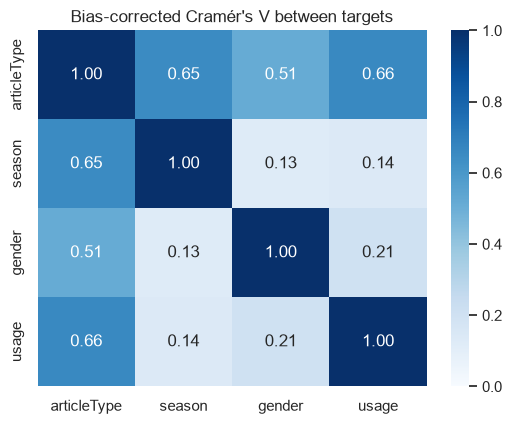

,value
possible combinations,40.0
observed combinations,24.0
combinations below 10 images,6.0
singleton combinations,3.0
largest/smallest ratio,15686.0


In [22]:
def corrected_cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.empty or min(table.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(k_corr - 1, r_corr - 1)
    return math.sqrt(phi2_corr / denominator) if denominator > 0 else np.nan


association = pd.DataFrame(index=TARGETS, columns=TARGETS, dtype=float)
for left in TARGETS:
    for right in TARGETS:
        pair = model_ready[[left, right]].dropna()
        association.loc[left, right] = (
            1.0 if left == right else corrected_cramers_v(pair[left], pair[right])
        )

fig, ax = plt.subplots(figsize=(5.5, 4.4))
sns.heatmap(association, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Bias-corrected Cramér's V between targets")
plt.tight_layout(); plt.show()

combination_counts = (
    model_ready.dropna(subset=["gender", "usage"])
    .assign(gender_usage=lambda d: d["gender"].astype(str) + " | " + d["usage"].astype(str))
    ["gender_usage"].value_counts()
)
display(pd.Series({
    "possible combinations": model_ready["gender"].nunique() * model_ready["usage"].nunique(),
    "observed combinations": len(combination_counts),
    "combinations below 10 images": int((combination_counts < 10).sum()),
    "singleton combinations": int((combination_counts == 1).sum()),
    "largest/smallest ratio": combination_counts.max() / combination_counts.min(),
}, name="value").to_frame())

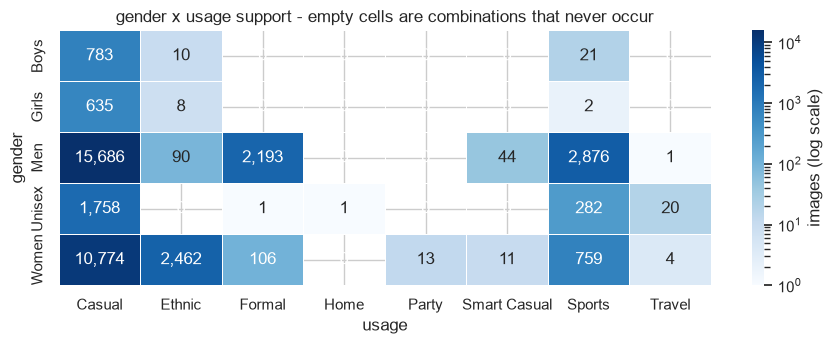

In [23]:
combination_matrix = pd.crosstab(model_ready["gender"], model_ready["usage"])
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(combination_matrix, annot=True, fmt=",d", cmap="Blues",
            norm=LogNorm(vmin=1, vmax=max(combination_matrix.to_numpy().max(), 2)),
            linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"label": "images (log scale)"})
ax.set_title("gender x usage support - empty cells are combinations that never occur")
plt.tight_layout(); plt.show()

**What we found.** The targets are related but far from redundant. If gender largely determined
usage, one head could predict both and the second would be free; the association is not nearly
strong enough for that.

The combination table settles it. Five gender labels and eight usage labels allow **40
combinations. Only 24 occur.** Of those, **6 hold fewer than 10 images and 3 are singletons.**

The heatmap shows the shape of that sparsity: the blanks are combinations that never occur at
all, and the log colour scale is necessary because the populated cells span four orders of
magnitude. A joint target would have to carry every one of those blanks as a class it can never
learn.

**The decision.** *One joint class* was rejected on two counts. It compounds sparsity — a
24-class target with singleton classes is harder than either of its parts, and creates exactly
the untrainable-class problem §2.2 documented, for no gain. And it silently discards rows: the 72
rows with `gender` but no `usage` have no valid joint label, so they would be dropped from a task
they are perfectly usable for.

*Two separate heads* was chosen. Each head sees every row that carries its own label, and a row
missing one label contributes to the other head with the missing head's loss masked to zero. This
is what the `-1` target and `_mask` columns in §3.2 implement.

## 2.5 Can the metadata columns be model inputs?

**The question.** The CSV carries five columns that are not prediction targets:
`masterCategory`, `subCategory`, `baseColour`, `year`, and `productDisplayName`. They are
strongly informative about the targets — `subCategory` alone nearly determines `articleType` —
so treating them as features is tempting.

The constraint that settles this is not statistical. `styles_prediction.csv` supplies `id` and
the four target columns and nothing else, so **none of these columns exist at prediction time.**
A model that consumes them cannot be run on the test set at all.

The cell below quantifies how much of the answer they carry, to show what is being given up and
to make the leakage concrete rather than asserted.

In [24]:
# How much of each target is already spelled out in the product name?
# Crude substring test (singular stem, case-insensitive) - it under-counts rather than over-counts.
leak_rows = []
for target in TARGETS:
    frame = model_ready.dropna(subset=["productDisplayName", target])
    contains = frame.apply(
        lambda row: str(row[target]).rstrip("s").lower() in row["productDisplayName"].lower(),
        axis=1,
    )
    leak_rows.append({
        "Target": target,
        "Rows with a product name": len(frame),
        "Label appears in the name": int(contains.sum()),
        "Share %": contains.mean() * 100,
    })
display(pd.DataFrame(leak_rows).style.format({"Share %": "{:.1f}%"}))

print("Example product names:")
for name in model_ready["productDisplayName"].dropna().head(5):
    print("  ", name)

,Target,Rows with a product name,Label appears in the name,Share %
0,articleType,38605,24276,62.9%
1,season,38585,25,0.1%
2,gender,38605,36677,95.0%
3,usage,38538,4103,10.6%


Example product names:
   Nike Sahara Team India Fanwear Round Neck Jersey
   Nike Men Blue T20 Indian Cricket Jersey
   Nike Mean Team India Cricket Jersey
   Puma Deck Navy Blue Backpack
   Puma Big Cat Backpack Black


**What we found.** `productDisplayName` contains the label outright for **95.0% of `gender`** and
**62.9% of `articleType`** rows — and that is a crude substring test, so the true figure is
higher. Names like "Turtle Check Men Navy Blue Shirt" state the gender, the colour and the item
type in plain text. `usage` appears in 10.6% and `season` in 0.1%, so the text is far more
informative about what a thing *is* than about when it is *for*.

**The decision.** These columns are **excluded as model inputs**, for all four tasks. Not because
they are weak — because they are unavailable at inference. A Task 1 model reading
`productDisplayName` would report a spectacular validation score and then be unable to produce a
single test prediction. The assignment's question is "what type of fashion item is shown in the
**image**", and the pixels are the only input that exists on both sides.

Two consequences worth stating rather than leaving implicit.

They remain in `model_ready` deliberately, for diagnostics. §2.3 already uses `subCategory` to
group article types into product families; that is analysis of the data, not a feature fed to a
model, and the distinction is what keeps it legitimate.

And "not an input" is not the same as "useless". `masterCategory` and `subCategory` are available
during *training* even though they are absent at inference, which makes them valid **auxiliary
supervision** — a hierarchical or multi-task loss that predicts the parent category alongside
`articleType` uses them to shape the representation and needs nothing extra at test time. We do
not implement that here, but it is a legitimate improvement for the task sections and a better
use of the columns than discarding them.

`productDisplayName` is kept too, though it is the one column with no defensible modelling use.
Its value is evidential: the 21 repaired rows in §1.1 are the reason we know the parse is sound.

# 3. What every task inherits

Two things are frozen here so that the four task sections run on identical inputs and produce
comparable numbers: the label encodings, and the image transform.

## 3.1 Freezing the label encodings

**The question.** Each task maps class names to integer indices. If a task builds its own mapping
from whatever labels happen to be present in its filtered subset, index 7 means something
different in each notebook section, and any confusion matrix or per-class score becomes
incomparable across models. The mapping is therefore built once, here, from the full label space.

In [25]:
label_maps = {}
for target in TARGETS:
    values = sorted(model_ready.loc[model_ready[target].notna(), target].unique())
    label_maps[target] = {label: index for index, label in enumerate(values)}
    model_ready[f"{target}_target"] = (
        model_ready[target].map(label_maps[target]).fillna(-1).astype(int)
    )
    model_ready[f"{target}_mask"] = model_ready[target].notna().astype(int)

display(pd.DataFrame([
    {"target": t, "classes": len(m), "index 0": list(m)[0], "index n-1": list(m)[-1]}
    for t, m in label_maps.items()
]))

for target in TARGETS:
    assert model_ready.loc[model_ready[f"{target}_mask"].eq(1), f"{target}_target"].ge(0).all()
    assert model_ready.loc[model_ready[f"{target}_mask"].eq(0), f"{target}_target"].eq(-1).all()

print("model_ready columns:", list(model_ready.columns))
print("model_ready shape:", model_ready.shape)

,target,classes,index 0,index n-1
0,articleType,124,Accessory Gift Set,Wristbands
1,season,4,Fall,Winter
2,gender,5,Boys,Women
3,usage,8,Casual,Travel


model_ready columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'filename', 'path', 'group_id', 'image_readable', 'task1_valid', 'task2_valid', 'task3_gender_valid', 'task3_usage_valid', 'task4_valid', 'articleType_target', 'articleType_mask', 'season_target', 'season_mask', 'gender_target', 'gender_mask', 'usage_target', 'usage_mask']
model_ready shape: (38612, 27)


**What we found.** The encodings cover **124 article types, 4 seasons, 5 genders, and 8 usages**,
sorted alphabetically so the mapping is reproducible without storing it.

Missing labels take target `-1` with mask `0`, which is the mechanism §2.4 called for. The two
assertions verify both halves: every masked-in row has a valid non-negative index, and every
masked-out row is `-1`. That prevents the failure mode where `-1` is quietly treated as a real
class index and trains the model to predict a category that does not exist.

## 3.2 Image properties, and the transform they imply

**The question.** A model needs a fixed-size tensor, and these files are not uniform. What the
transform has to absorb is a question about the actual images, so we measure first and decide
after.

In [26]:
dimension_counts = (
    readable_audit.groupby(["width", "height"]).size()
    .sort_values(ascending=False).rename("images")
)
mode_counts = readable_audit["mode"].value_counts().rename("images")

display(readable_audit[["file_bytes", "width", "height", "aspect_ratio"]].describe().T)
display(dimension_counts.head(10).to_frame())
display(mode_counts.to_frame())
print("Formats:", readable_audit["format"].value_counts().to_dict())
print(f"Grayscale images: {int(readable_audit['is_grayscale'].sum()):,} "
      f"({readable_audit['is_grayscale'].mean() * 100:.2f}%)")
print(f"Median aspect ratio (w/h): {readable_audit['aspect_ratio'].median():.3f}")

,count,mean,std,min,25%,50%,75%,max
file_bytes,38612.0,12480.446364,10059.295638,481.0000,2170.00,13831.00,20364.00,110353.0
width,38612.0,59.998550,0.100749,53.0000,60.00,60.00,60.00,60.0
height,38612.0,79.997022,0.230907,60.0000,80.00,80.00,80.00,80.0
aspect_ratio,38612.0,0.750018,0.003135,0.6625,0.75,0.75,0.75,1.0


images
width height        
60    80       38595
53    80           8
60    60           5
      77           2
      76           1
      75           1

,images
mode,
RGB,38269
L,343


Formats: {'JPEG': 38612}
Grayscale images: 343 (0.89%)
Median aspect ratio (w/h): 0.750


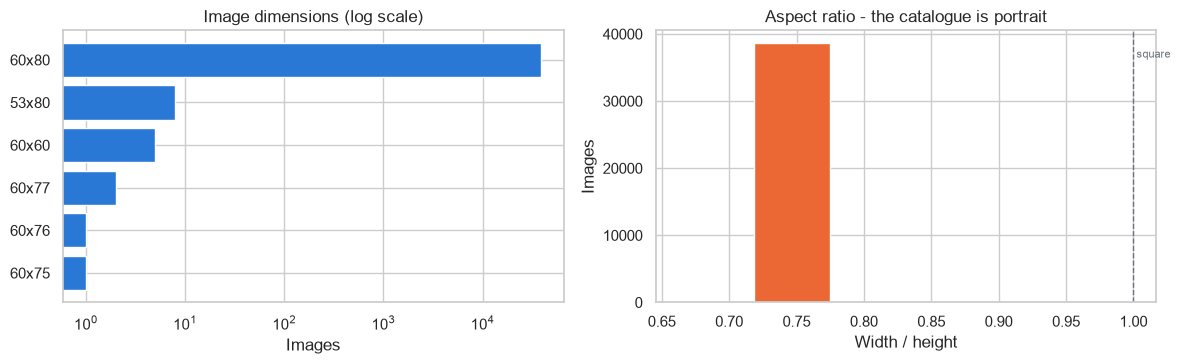

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
top_dimensions = dimension_counts.head(8).sort_values()
axes[0].barh([f"{int(w)}x{int(h)}" for w, h in top_dimensions.index], top_dimensions.values,
             color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set(title="Image dimensions (log scale)", xlabel="Images")
axes[1].hist(readable_audit["aspect_ratio"],
             bins=min(30, max(5, readable_audit["aspect_ratio"].nunique())),
             color=PALETTE[1], edgecolor="white")
axes[1].axvline(1.0, color=MUTED, ls="--", lw=1)
axes[1].text(1.0, axes[1].get_ylim()[1] * 0.9, " square", fontsize=8, color=MUTED)
axes[1].set(title="Aspect ratio - the catalogue is portrait", xlabel="Width / height", ylabel="Images")
plt.tight_layout(); plt.show()

**What we found.** The catalogue is far more standardised than a scraped dataset would be.
**38,595 of 38,612 images are exactly 60x80** — small, portrait, consistent. **17 images** spread
across five other size pairs. **343 images (0.89%) are single-channel grayscale.** All are JPEG.
The median aspect ratio is **0.75**, confirming the portrait orientation is systematic rather than
incidental.

Two facts drive everything below: the images are tiny, and they are portrait. The aspect-ratio
histogram is effectively a spike at 0.75 with a few strays, and the dimension chart needs a log
axis for the 17 exceptions to be visible at all next to the 38,595.

**The decision — geometry.** Three ways to reach a fixed size.

*Centre-crop to a square.* Rejected. At an aspect ratio of 0.75, cropping to square removes a
quarter of the image, and on a portrait product photo that quarter is the top or bottom of the
garment. Losing the collar of a shirt or the heel of a boot destroys the silhouette, which §2.3
suggests is the main cue separating article types.

*Stretch to a square.* Rejected for the same reason from the other direction: it preserves all the
content but distorts proportions, and proportion is exactly what distinguishes a long garment
from a short one.

*Fit proportionally, then pad.* Chosen. Nothing is removed and nothing is distorted; the cost is
uniform white padding, which matches the existing white product backgrounds rather than
introducing a new visual artefact.

**The decision — size.** `IMAGE_TARGET_SIZE` defaults to the catalogue's **own modal size**, read
from the audit rather than hard-coded. Because 99.96% of images already match it, the transform
short-circuits for almost all of them and the pixels reach the model untouched — no resampling,
no invented detail. Only the 17 odd-sized files are actually resized, which is the minimum needed
for batching to work.

Upscaling to a larger square — 224x224, say — was rejected *as a default*, not as an idea. It
costs roughly fourteen times the pixels per image and cannot add information the 60x80 source does
not contain, so it has to earn its place with a validation score rather than being assumed. It is
also the change needed to compare against a pretrained backbone, most of which expect a larger
input. Because size is a single constant and the pad geometry is fixed at every size, that
experiment is one line and changes resolution and nothing else.

The before/after figure verifies the claim rather than asserting it: the typical files are
untouched, and only the atypical ones show padding. It is also the check that would catch a
regression if the size constant is changed later.

**Deferred.** Normalisation constants are not computed here. They must be fitted on training rows
only, no split exists yet, and they are size-specific — padding with white shifts the RGB mean, so
a run at 224 needs its own constants rather than reusing these.

Native size 60x80 covers 38,595 images (99.96%); 17 images need resizing.
Transform verified at (60, 80) on 7 images covering every observed size and colour mode.


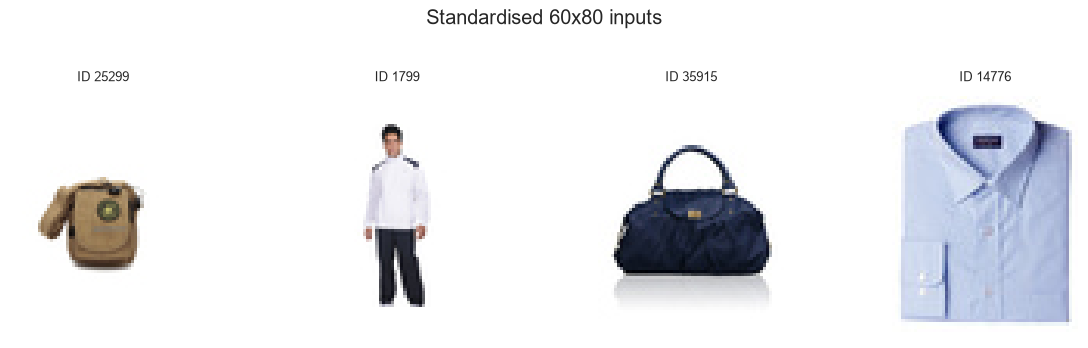

In [28]:
# Default: the catalogue's own modal size, so most images pass through unresized.
# Experiment later by overriding this one constant, e.g. IMAGE_TARGET_SIZE = (224, 224).
NATIVE_IMAGE_SIZE = tuple(int(v) for v in dimension_counts.index[0])  # (width, height)
IMAGE_TARGET_SIZE = NATIVE_IMAGE_SIZE
IMAGE_PAD_RGB = (255, 255, 255)

native_share = dimension_counts.iloc[0] / dimension_counts.sum() * 100
print(f"Native size {NATIVE_IMAGE_SIZE[0]}x{NATIVE_IMAGE_SIZE[1]} covers "
      f"{dimension_counts.iloc[0]:,} images ({native_share:.2f}%); "
      f"{int(dimension_counts.iloc[1:].sum()):,} images need resizing.")


def standardize_image(image, target_size=IMAGE_TARGET_SIZE):
    """Deterministic Task 1-4 input transform. Augmentation goes after this, normalisation last."""
    image = ImageOps.exif_transpose(image).convert("RGB")
    if image.size == tuple(target_size):
        return image  # already the target size: no resampling at all
    return ImageOps.pad(
        image, target_size, method=Image.Resampling.BILINEAR,
        color=IMAGE_PAD_RGB, centering=(0.5, 0.5),
    )


# Verify the transform against every observed source dimension and one grayscale file.
check_ids = readable_audit.groupby(["width", "height"], sort=True)["id"].first().tolist()
grayscale_ids = readable_audit.loc[readable_audit["is_grayscale"], "id"]
if len(grayscale_ids):
    check_ids.append(int(grayscale_ids.iloc[0]))

path_by_id = readable_audit.set_index("id")["path"]
for check_id in dict.fromkeys(map(int, check_ids)):
    with Image.open(path_by_id.loc[check_id]) as image:
        standardized = standardize_image(image)
    assert standardized.size == IMAGE_TARGET_SIZE and standardized.mode == "RGB"
print(f"Transform verified at {IMAGE_TARGET_SIZE} on {len(set(check_ids))} images "
      f"covering every observed size and colour mode.")

sample_ids = list(dict.fromkeys(map(int, check_ids)))[:4]
fig, axes = plt.subplots(1, len(sample_ids), figsize=(3 * len(sample_ids), 3.4))
for ax, sample_id in zip(np.atleast_1d(axes), sample_ids):
    with Image.open(path_by_id.loc[sample_id]) as image:
        ax.imshow(standardize_image(image))
    ax.set_title(f"ID {sample_id}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Standardised {IMAGE_TARGET_SIZE[0]}x{IMAGE_TARGET_SIZE[1]} inputs", y=1.02)
plt.tight_layout(); plt.show()

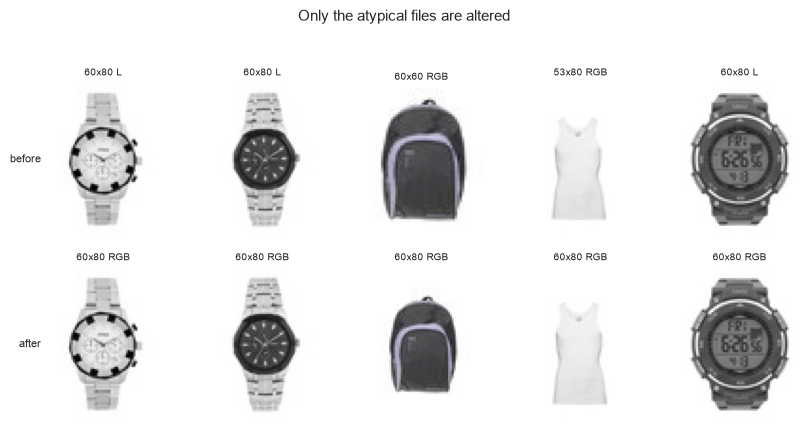

In [29]:
# Before and after, on the files the transform actually has to change.
awkward = pd.concat([odd_sized, grayscale_files]).drop_duplicates("id")
before_after = sample_paths(awkward, 5, seed_offset=4)
if before_after:
    fig, axes = plt.subplots(2, len(before_after), figsize=(1.7 * len(before_after), 4.2), squeeze=False)
    for column, record in enumerate(before_after):
        with Image.open(record.path) as image:
            original = ImageOps.exif_transpose(image).convert("RGB")
            transformed = standardize_image(image)
        for row_index, (picture, caption) in enumerate(
            [(original, f"{original.size[0]}x{original.size[1]} {record.mode}"),
             (transformed, f"{transformed.size[0]}x{transformed.size[1]} RGB")]
        ):
            ax = axes[row_index][column]
            ax.imshow(picture)
            ax.set_title(caption, fontsize=7)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
    axes[0][0].set_ylabel("before", fontsize=8, rotation=0, ha="right", va="center")
    axes[1][0].set_ylabel("after", fontsize=8, rotation=0, ha="right", va="center")
    fig.suptitle("Only the atypical files are altered", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

---

# Everything below is task-specific

Tasks 1–4 continue from here. Each task section is self-contained apart from three shared
objects defined above: `model_ready`, `label_maps`, and `standardize_image()`.

Two rules every task section must follow, both of them consequences of findings above:

1. Build its split with `group_id` as the grouping key (§1.6), so byte-identical images cannot
   appear on both sides.
2. Fit any preprocessing statistic — normalisation constants, encoders, scalers — on training
   rows only, then apply it unchanged to validation.

`IMAGE_TARGET_SIZE` is the one knob deliberately left open: the default keeps images at their
native resolution, and any task section may rerun itself at a larger size to test whether the
extra pixels pay for themselves.